We will now perform cross-validation on a simulated data set.



(a) Generate a simulated data set as follows:
rng = np.random.default_rng(1)
x = rng.normal(size=100)
y = x - 2 * x**2 + rng.normal(size=100)
In this data set, what is n and what is p? Write out the model
used to generate the data in equation form.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import PolynomialFeatures

import statsmodels.api as sm

rng = np.random.default_rng(1)

n = 100
x = rng.normal(size=n)
eps = rng.normal(size=n)
y = x - 2 * x**2 + eps

print("n =", n)
print("p = 2")
print("y = x - 2 * x**2 + eps")


n = 100
p = 2
y = x - 2 * x**2 + eps


(b) Create a scatterplot of X against Y . Comment on what you find.


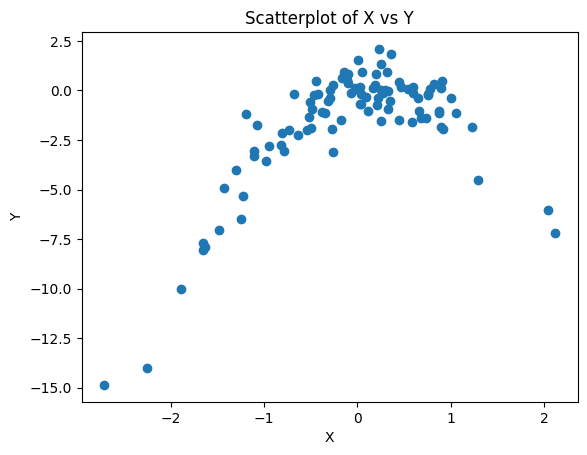

In [3]:
plt.figure()
plt.scatter(x, y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Scatterplot of X vs Y")
plt.show()


(c) Set a random seed, and then compute the LOOCV errors that
result from fitting the following four models using least squares:
i. Y = β0 + β1X + "
ii. Y = β0 + β1X + β2X2 + "
iii. Y = β0 + β1X + β2X2 + β3X3 + "
iv. Y = β0 + β1X + β2X2 + β3X3 + β4X4 + ".
Note you may find it helpful to use the data.frame() function
to create a single data set containing both X and Y .

In [4]:
def loocv_mse(x, y, degree):

    x = x.reshape(-1, 1)

    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(x)

    loo = LeaveOneOut()
    model = LinearRegression()

    sq_errors = []

    for train_idx, test_idx in loo.split(X_poly):
        X_train, X_test = X_poly[train_idx], X_poly[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        sq_errors.append((y_test[0] - y_pred[0])**2)

    mse = np.mean(sq_errors)
    return mse

degrees = [1, 2, 3, 4]
loocv_results_seed1 = {}

for d in degrees:
    mse = loocv_mse(x, y, degree=d)
    loocv_results_seed1[d] = mse

print("LOOCV MSE（random seed = 1）:")
for d, mse in loocv_results_seed1.items():
    print(f"degree {d}: {mse:.4f}")


LOOCV MSE（random seed = 1）:
degree 1: 6.6330
degree 2: 1.1229
degree 3: 1.3018
degree 4: 1.3324


(d) Repeat (c) using another random seed, and report your results.
Are your results the same as what you got in (c)? Why?

In [5]:
rng2 = np.random.default_rng(123)
x2 = rng2.normal(size=n)
eps2 = rng2.normal(size=n)
y2 = x2 - 2 * x2**2 + eps2

loocv_results_seed2 = {}
for d in degrees:
    mse = loocv_mse(x2, y2, degree=d)
    loocv_results_seed2[d] = mse

print("\nLOOCV MSE（random seed = 123）:")
for d, mse in loocv_results_seed2.items():
    print(f"degree {d}: {mse:.4f}")



LOOCV MSE（random seed = 123）:
degree 1: 5.3630
degree 2: 0.8871
degree 3: 0.9129
degree 4: 0.9561


(e) Which of the models in (c) had the smallest LOOCV error? Is
this what you expected? Explain your answer.


In [6]:
def best_degree(loocv_dict):
    best_d = min(loocv_dict, key=loocv_dict.get)
    return best_d, loocv_dict[best_d]

best_d1, best_mse1 = best_degree(loocv_results_seed1)
best_d2, best_mse2 = best_degree(loocv_results_seed2)

print(f"\nSeed 1：Best degree = {best_d1}, LOOCV MSE = {best_mse1:.4f}")
print(f"Seed 2：Best degree = {best_d2}, LOOCV MSE = {best_mse2:.4f}")



Seed 1：Best degree = 2, LOOCV MSE = 1.1229
Seed 2：Best degree = 2, LOOCV MSE = 0.8871


(f) Comment on the statistical significance of the coefficient estimates that results from fitting each of the models in (c) using
least squares. Do these results agree with the conclusions drawn
based on the cross-validation results?

In [7]:
def fit_poly_ols(x, y, degree):
    x = x.reshape(-1, 1)
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(x)

    X_poly_with_const = sm.add_constant(X_poly)

    model = sm.OLS(y, X_poly_with_const)
    results = model.fit()
    print(f"\n===== degree = {degree} OLS results=====")
    print(results.summary())
    return results

results_deg1 = fit_poly_ols(x, y, degree=1)
results_deg2 = fit_poly_ols(x, y, degree=2)
results_deg3 = fit_poly_ols(x, y, degree=3)
results_deg4 = fit_poly_ols(x, y, degree=4)



===== degree = 1 OLS results=====
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.311
Method:                 Least Squares   F-statistic:                     45.60
Date:                Fri, 14 Nov 2025   Prob (F-statistic):           1.04e-09
Time:                        13:07:36   Log-Likelihood:                -230.83
No. Observations:                 100   AIC:                             465.7
Df Residuals:                      98   BIC:                             470.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.